# SEA-DP Dataset Exploratory Data Analysis
### Data Mining Course — Polytechnic University of the Philippines
**Topology-Preserving Polygon Simplification Using a Shared-Edge-Aware Douglas–Peucker Algorithm**

This notebook explores the raw geospatial datasets used in the SEA-DP study **before any simplification is applied**.
It demonstrates what geospatial vector data looks like as a data structure, and visualizes the three complexity tiers used in the evaluation.

---

## 0. Setup — Imports and File Paths
Update the file paths below to match your local directory.

In [9]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import numpy as np
from shapely.validation import make_valid

# ── UPDATE THESE PATHS TO YOUR LOCAL FILES ──────────────────────────────────
PATH_PH = '../../data/raw/GADM/philippines/gadm41_PHL_1.shp'
PATH_US = '../../data/raw/natural_earth/USA/ne_10m_admin_1_states_provinces/ne_10m_admin_1_states_provinces.shp'
PATH_INTL = '../../data/raw/natural_earth/Armenia-Azerbaijan/ne_10m_admin_0_countries/ne_10m_admin_0_countries.shp'
# ────────────────────────────────────────────────────────────────────────────

# Pairs per tier
US_PAIRS = [
    ('California', 'Nevada'),
    ('New Mexico', 'Texas'),
    ('Nevada', 'Utah'),
    ('Utah', 'Wyoming'),
]

PH_PAIRS = [
    ('Laguna', 'Quezon'),
    ('Rizal', 'Laguna'),
    ('Cavite', 'Laguna'),
    ('Rizal', 'Metropolitan Manila'),
]

INTL_PAIRS = [
    ('Armenia', 'Azerbaijan'),
    ('United Arab Emirates', 'Oman'),
    ('Kyrgyzstan', 'Tajikistan'),
    ('Uzbekistan', 'Kyrgyzstan'),
]

print('Libraries loaded successfully!')

Libraries loaded successfully!


---
## 1. Loading the Data
Geospatial vector data is loaded into a **GeoDataFrame** — think of it like a pandas DataFrame, but with a special `geometry` column that stores polygon coordinates instead of plain numbers.

In [2]:
# Load all three datasets
gdf_ph   = gpd.read_file(PATH_PH)
gdf_us   = gpd.read_file(PATH_US)
gdf_intl = gpd.read_file(PATH_INTL)

print(f'Philippines (GADM L1): {len(gdf_ph):>5} features | CRS: {gdf_ph.crs}')
print(f'US States (Nat. Earth): {len(gdf_us):>4} features | CRS: {gdf_us.crs}')
print(f'Countries (Nat. Earth): {len(gdf_intl):>4} features | CRS: {gdf_intl.crs}')

Philippines (GADM L1):    81 features | CRS: EPSG:4326
US States (Nat. Earth): 4596 features | CRS: EPSG:4326
Countries (Nat. Earth):  258 features | CRS: EPSG:4326


### 1.1 What does a GeoDataFrame look like?
This is the most important cell for understanding the data structure — the `geometry` column is what makes it geospatial.

In [3]:
# Show the Philippines GeoDataFrame as a table
# Notice the 'geometry' column — that's the polygon coordinates
display(gdf_ph[['NAME_1', 'geometry']].head(10))

,NAME_1,geometry
0,Abra,"POLYGON ((120.74773 17.15755, 120.73747 17.156..."
1,Agusan del Norte,"POLYGON ((125.51141 8.70021, 125.49689 8.70089..."
2,Agusan del Sur,"POLYGON ((126.05209 7.93625, 126.04572 7.93504..."
3,Aklan,"MULTIPOLYGON (((122.28702 11.74581, 122.28805 ..."
4,Albay,"MULTIPOLYGON (((123.4464 13.02776, 123.44541 1..."
5,Antique,"MULTIPOLYGON (((121.95645 10.41523, 121.95607 ..."
6,Apayao,"POLYGON ((121.11682 17.74139, 121.11263 17.768..."
7,Aurora,"MULTIPOLYGON (((121.40289 15.24627, 121.40344 ..."
8,Basilan,"MULTIPOLYGON (((121.98666 6.30861, 121.98695 6..."
9,Bataan,"MULTIPOLYGON (((120.62193 14.36568, 120.62153 ..."


In [6]:
# Peek at one polygon's raw coordinate data
sample = gdf_ph[gdf_ph['NAME_1'] == 'Laguna'].iloc[0].geometry

print(f'Geometry type : {sample.geom_type}')
print(f'Is valid      : {sample.is_valid}')
print(f'Bounding box  : {sample.bounds}')
print(f'Area (sq deg) : {sample.area:.6f}')
print(f'Exterior ring vertices: {len(list(sample.exterior.coords))}')
print(f'Interior rings (holes): {len(list(sample.interiors))}')
print(f'\nFirst 5 coordinate pairs of exterior ring:')
for coord in list(sample.exterior.coords)[:5]:
    print(f'  {coord}')

Geometry type : Polygon
Is valid      : True
Bounding box  : (121.00533294800016, 13.964179994000006, 121.63243865900017, 14.57583046000019)
Area (sq deg) : 0.225884
Exterior ring vertices: 2343
Interior rings (holes): 7

First 5 coordinate pairs of exterior ring:
  (121.33809661800001, 13.996529580000015)
  (121.33695984000008, 13.994549752000182)
  (121.333343506, 13.991479873000117)
  (121.33252716000015, 13.988450051000086)
  (121.32972717300004, 13.986590387000035)


---
## 2. Data Inspection — Descriptive Statistics
Before any processing, we inspect the geometric properties of the raw data.

In [4]:
def count_vertices(geom):
    """Count all vertices in a polygon or multipolygon."""
    if geom is None or geom.is_empty:
        return 0
    if geom.geom_type == 'Polygon':
        return len(list(geom.exterior.coords)) + sum(len(list(r.coords)) for r in geom.interiors)
    if geom.geom_type == 'MultiPolygon':
        return sum(count_vertices(p) for p in geom.geoms)
    return 0

def describe_gdf(gdf, name_col, names, label):
    """Compute descriptive geometric stats for a list of named features."""
    rows = []
    for name in names:
        subset = gdf[gdf[name_col] == name]
        if subset.empty:
            continue
        g = subset.iloc[0].geometry
        if g and not g.is_empty:
            rows.append({
                'Name'          : name,
                'Geometry Type' : g.geom_type,
                'Vertices'      : count_vertices(g),
                'Interior Rings': len(list(g.interiors)) if g.geom_type == 'Polygon' else
                                  sum(len(list(p.interiors)) for p in g.geoms),
                'Is Valid'      : g.is_valid,
                'Parts'         : len(g.geoms) if g.geom_type == 'MultiPolygon' else 1,
            })
    df = pd.DataFrame(rows)
    print(f'\n── {label} ──────────────────────────────')
    display(df)
    print(f'Total vertices: {df["Vertices"].sum():,}  |  Mean: {df["Vertices"].mean():.0f}  |  Max: {df["Vertices"].max()}')
    return df

# Flatten all names per tier
us_names   = list(set([n for pair in US_PAIRS for n in pair]))
ph_names   = list(set([n for pair in PH_PAIRS for n in pair]))
intl_names = list(set([n for pair in INTL_PAIRS for n in pair]))

df_us   = describe_gdf(gdf_us,   'name',   us_names,   'LOW COMPLEXITY — US States')
df_ph   = describe_gdf(gdf_ph,   'NAME_1', ph_names,   'MODERATE COMPLEXITY — Philippine Provinces')
df_intl = describe_gdf(gdf_intl, 'NAME_EN', intl_names, 'HIGH COMPLEXITY — International Boundaries')


── LOW COMPLEXITY — US States ──────────────────────────────


,Name,Geometry Type,Vertices,Interior Rings,Is Valid,Parts
0,Utah,Polygon,149,0,True,1
1,California,MultiPolygon,1856,0,True,8
2,Wyoming,Polygon,199,0,True,1
3,Nevada,Polygon,220,0,True,1
4,Arizona,Polygon,424,0,True,1
5,New Mexico,Polygon,320,0,True,1


Total vertices: 3,168  |  Mean: 528  |  Max: 1856

── MODERATE COMPLEXITY — Philippine Provinces ──────────────────────────────


,Name,Geometry Type,Vertices,Interior Rings,Is Valid,Parts
0,Cavite,MultiPolygon,2908,0,True,2
1,Quezon,MultiPolygon,26508,0,True,55
2,Rizal,MultiPolygon,2680,0,True,8
3,Laguna,Polygon,2560,7,True,1
4,Metropolitan Manila,MultiPolygon,6755,1,True,3


Total vertices: 41,411  |  Mean: 8282  |  Max: 26508

── HIGH COMPLEXITY — International Boundaries ──────────────────────────────


,Name,Geometry Type,Vertices,Interior Rings,Is Valid,Parts
0,Oman,MultiPolygon,1033,1,True,6
1,Azerbaijan,MultiPolygon,957,1,True,6
2,United Arab Emirates,MultiPolygon,798,1,True,10
3,Uzbekistan,MultiPolygon,1666,1,True,3
4,Kyrgyzstan,Polygon,1206,3,True,1
5,Tajikistan,MultiPolygon,1257,0,True,3
6,Armenia,MultiPolygon,434,2,True,2


Total vertices: 7,351  |  Mean: 1050  |  Max: 1666


In [5]:
# Summary comparison across tiers
summary = pd.DataFrame([
    {'Tier': 'Low (US States)',        'Avg Vertices': df_us['Vertices'].mean(),
     'Max Vertices': df_us['Vertices'].max(), 'MultiPolygon count': (df_us['Geometry Type']=='MultiPolygon').sum()},
    {'Tier': 'Moderate (PH Provinces)','Avg Vertices': df_ph['Vertices'].mean(),
     'Max Vertices': df_ph['Vertices'].max(), 'MultiPolygon count': (df_ph['Geometry Type']=='MultiPolygon').sum()},
    {'Tier': 'High (International)',   'Avg Vertices': df_intl['Vertices'].mean(),
     'Max Vertices': df_intl['Vertices'].max(), 'MultiPolygon count': (df_intl['Geometry Type']=='MultiPolygon').sum()},
]).round(0)

print('\n── CROSS-TIER SUMMARY ───────────────────────────────')
display(summary)


── CROSS-TIER SUMMARY ───────────────────────────────


,Tier,Avg Vertices,Max Vertices,MultiPolygon count
0,Low (US States),528.0,1856,1
1,Moderate (PH Provinces),8282.0,26508,4
2,High (International),1050.0,1666,6


---
## 3. Visualizing the Raw Data — All Three Complexity Tiers
Each pair is shown with both polygons colored differently so you can clearly see the shared boundary.

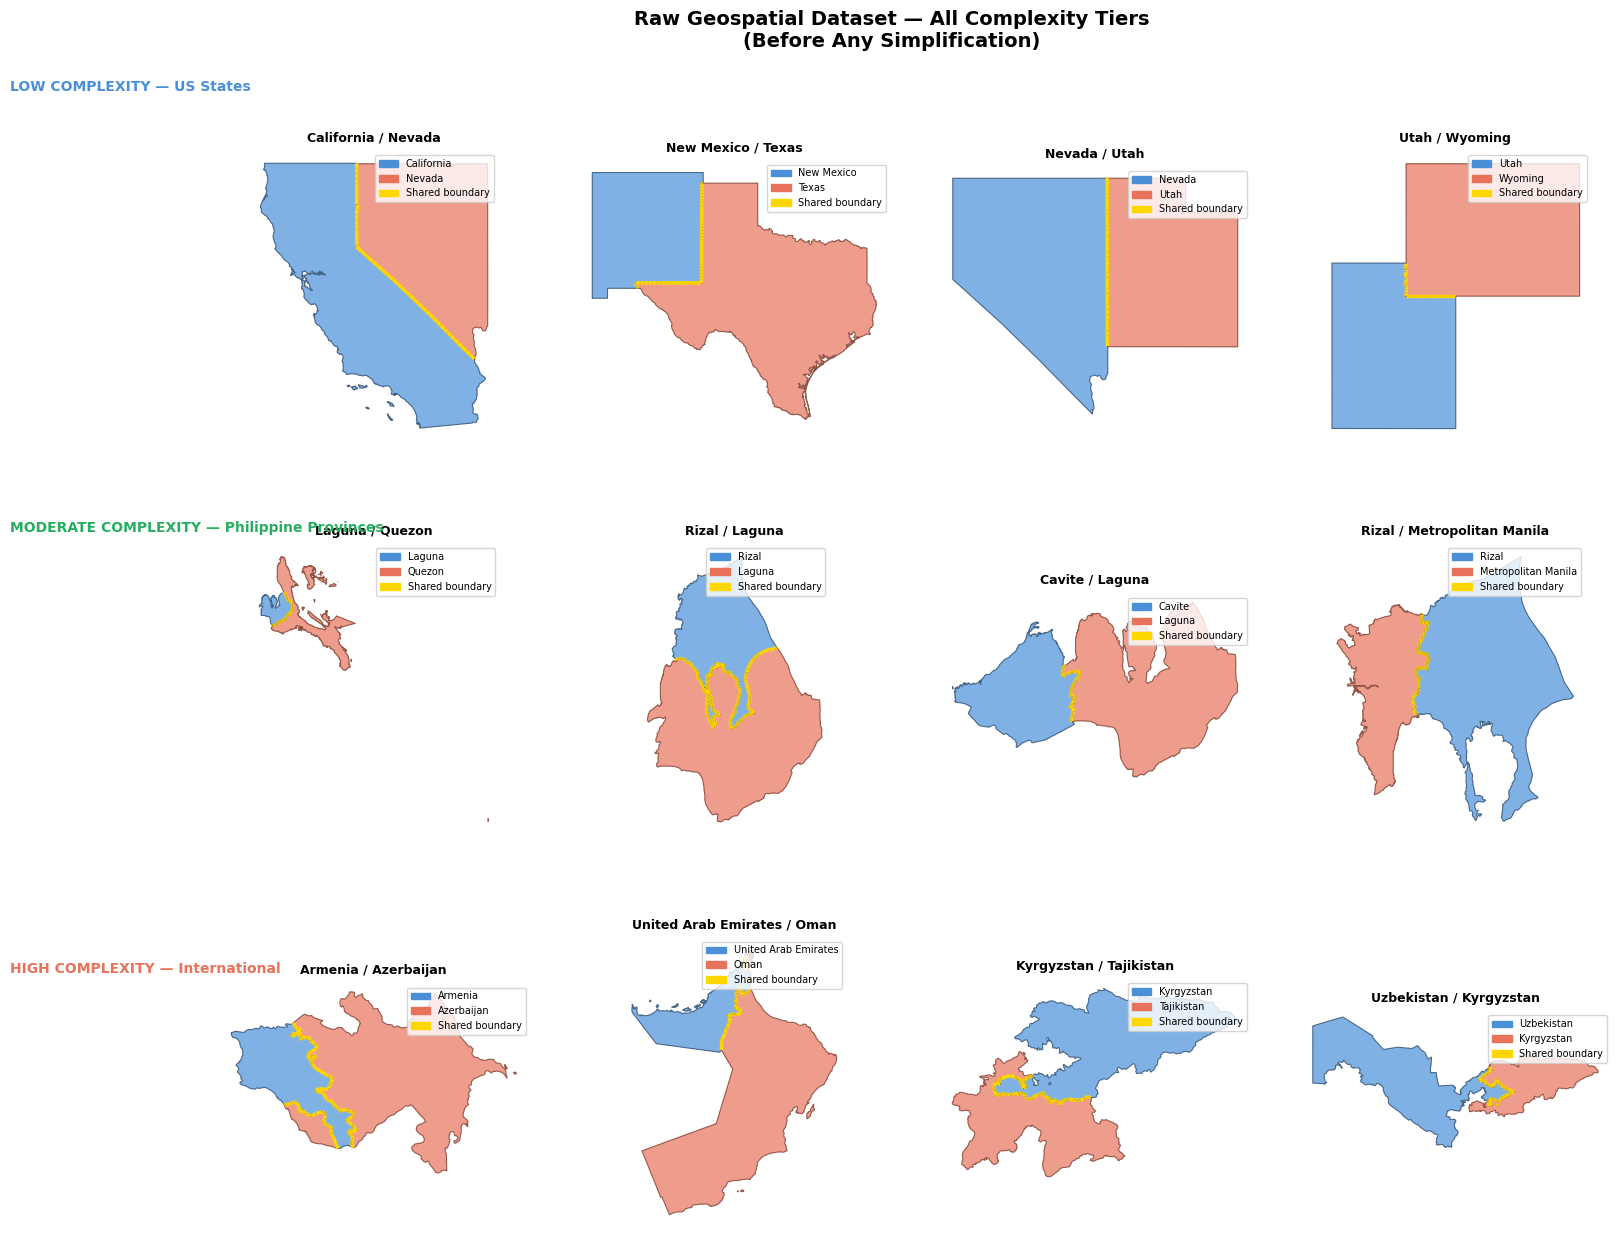

Saved as all_tiers_raw.png


In [10]:
def plot_pair(ax, gdf, name_col, left, right, title, crs_epsg=None):
    """Plot a polygon pair, highlighting the shared boundary."""
    left_row  = gdf[gdf[name_col] == left]
    right_row = gdf[gdf[name_col] == right]

    if left_row.empty or right_row.empty:
        ax.set_title(f'{title}\n(data not found)', fontsize=9, color='red')
        ax.axis('off')
        return

    if crs_epsg:
        left_row  = left_row.to_crs(epsg=crs_epsg)
        right_row = right_row.to_crs(epsg=crs_epsg)

    left_row.plot(ax=ax,  color='#4A90D9', edgecolor='#1A3A5C', linewidth=0.8, alpha=0.7)
    right_row.plot(ax=ax, color='#E8735A', edgecolor='#6B2A1A', linewidth=0.8, alpha=0.7)

    # Highlight shared boundary
    try:
        shared = left_row.iloc[0].geometry.boundary.intersection(
                 right_row.iloc[0].geometry.boundary)
        if not shared.is_empty:
            gpd.GeoSeries([shared], crs=left_row.crs).plot(
                ax=ax, color='#FFD700', linewidth=2.5, zorder=5)
    except Exception:
        pass

    p1 = mpatches.Patch(color='#4A90D9', label=left)
    p2 = mpatches.Patch(color='#E8735A', label=right)
    p3 = mpatches.Patch(color='#FFD700', label='Shared boundary')
    ax.legend(handles=[p1, p2, p3], fontsize=7, loc='best')
    ax.set_title(title, fontsize=9, fontweight='bold', pad=6)
    ax.set_axis_off()


fig = plt.figure(figsize=(18, 14))
fig.suptitle('Raw Geospatial Dataset — All Complexity Tiers\n(Before Any Simplification)',
             fontsize=14, fontweight='bold', y=0.98)

gs = gridspec.GridSpec(3, 4, figure=fig, hspace=0.35, wspace=0.15)

# LOW COMPLEXITY — US States
for i, (left, right) in enumerate(US_PAIRS):
    ax = fig.add_subplot(gs[0, i])
    plot_pair(ax, gdf_us, 'name', left, right, f'{left} / {right}', crs_epsg=None)

# MODERATE COMPLEXITY — Philippine Provinces
for i, (left, right) in enumerate(PH_PAIRS):
    ax = fig.add_subplot(gs[1, i])
    plot_pair(ax, gdf_ph, 'NAME_1', left, right, f'{left} / {right}', crs_epsg=32651)

# HIGH COMPLEXITY — International
for i, (left, right) in enumerate(INTL_PAIRS):
    ax = fig.add_subplot(gs[2, i])
    plot_pair(ax, gdf_intl, 'NAME_EN', left, right, f'{left} / {right}', crs_epsg=None)

# Tier labels
for row, label, color in [
    (0, 'LOW COMPLEXITY — US States',          '#4A90D9'),
    (1, 'MODERATE COMPLEXITY — Philippine Provinces', '#27AE60'),
    (2, 'HIGH COMPLEXITY — International',     '#E8735A'),
]:
    fig.text(0.01, 0.93 - row*0.315, label, fontsize=10,
             fontweight='bold', color=color, va='top')

plt.savefig('all_tiers_raw.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved as all_tiers_raw.png')

---
## 4. Zoomed View — The Shared Boundary Problem
This cell zooms into the shared boundary of a Philippine pair so you can clearly see what SEA-DP is solving.

C:\Users\erics\AppData\Local\Temp\ipykernel_26904\322053285.py:16: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  ax.legend(fontsize=9)


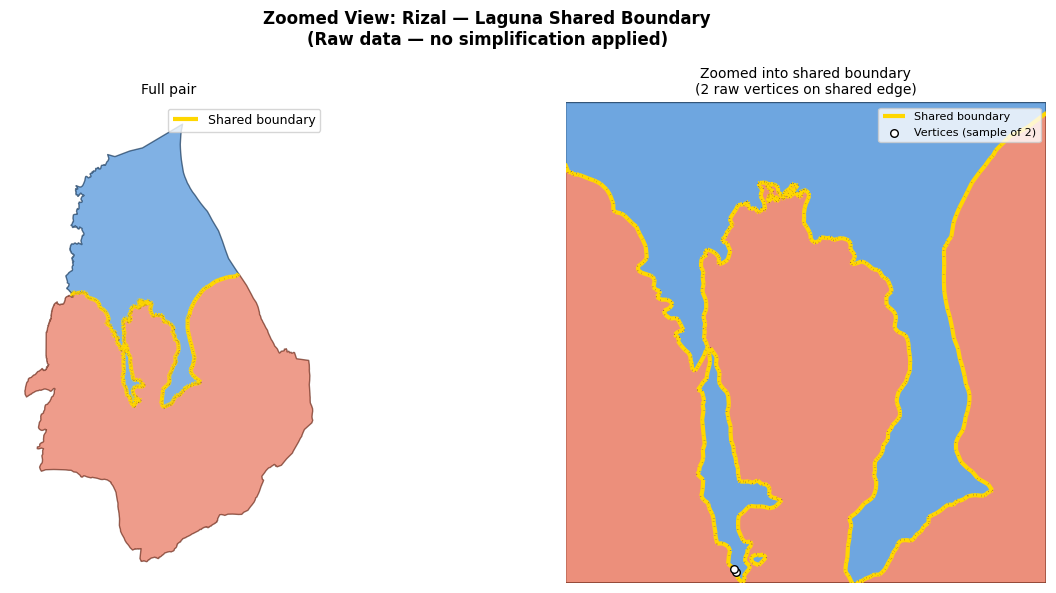

Saved as shared_boundary_zoom.png


In [28]:
# Focus on Rizal-Laguna — moderate complexity, clear shared border
rizal  = gdf_ph[gdf_ph['NAME_1'] == 'Rizal'].to_crs(epsg=32651)
laguna = gdf_ph[gdf_ph['NAME_1'] == 'Laguna'].to_crs(epsg=32651)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Zoomed View: Rizal — Laguna Shared Boundary\n(Raw data — no simplification applied)',
             fontsize=12, fontweight='bold')

# Full pair view
ax = axes[0]
rizal.plot(ax=ax,  color='#4A90D9', edgecolor='#1A3A5C', linewidth=1, alpha=0.7, label='Rizal')
laguna.plot(ax=ax, color='#E8735A', edgecolor='#6B2A1A', linewidth=1, alpha=0.7, label='Laguna')
shared = rizal.iloc[0].geometry.boundary.intersection(laguna.iloc[0].geometry.boundary)
if not shared.is_empty:
    gpd.GeoSeries([shared], crs=rizal.crs).plot(ax=ax, color='#FFD700', linewidth=3, label='Shared boundary')
ax.legend(fontsize=9)
ax.set_title('Full pair', fontsize=10)
ax.set_axis_off()

# Zoomed into shared boundary
ax = axes[1]
if not shared.is_empty:
    cx, cy = shared.centroid.x, shared.centroid.y
    zoom = 15000  # 15km zoom window
    rizal.clip([cx-zoom, cy-zoom, cx+zoom, cy+zoom]).plot(
        ax=ax, color='#4A90D9', edgecolor='#1A3A5C', linewidth=1.2, alpha=0.8)
    laguna.clip([cx-zoom, cy-zoom, cx+zoom, cy+zoom]).plot(
        ax=ax, color='#E8735A', edgecolor='#6B2A1A', linewidth=1.2, alpha=0.8)
    gpd.GeoSeries([shared], crs=rizal.crs).plot(
        ax=ax, color='#FFD700', linewidth=3, label='Shared boundary')
    ax.set_xlim(cx-zoom, cx+zoom)
    ax.set_ylim(cy-zoom, cy+zoom)
    
    # Annotate a few vertices to show raw coordinate density
    coords = list(shared.geoms[0].coords) if shared.geom_type == 'MultiLineString' else list(shared.coords)
    sample_coords = coords[::max(1, len(coords)//15)]  # sample ~15 points
    xs = [c[0] for c in sample_coords]
    ys = [c[1] for c in sample_coords]
    ax.scatter(xs, ys, color='white', edgecolor='black', s=30, zorder=10, label=f'Vertices (sample of {len(sample_coords)})')

ax.set_title(f'Zoomed into shared boundary\n({len(coords):,} raw vertices on shared edge)', fontsize=10)
ax.legend(fontsize=8)
ax.set_axis_off()

plt.tight_layout()
plt.savefig('shared_boundary_zoom.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved as shared_boundary_zoom.png')

---
## 5. Data Validation — Geometry Quality Check
Checking the raw data for any pre-existing geometry issues before simplification.

In [29]:
def validate_raw(gdf, name_col, names, tier_label):
    """Check geometry validity for selected features."""
    rows = []
    for name in names:
        subset = gdf[gdf[name_col] == name]
        if subset.empty:
            continue
        g = subset.iloc[0].geometry
        if g is None or g.is_empty:
            continue
        reason = '' if g.is_valid else str(g.is_valid)
        rows.append({
            'Feature'  : name,
            'Valid'    : '✓' if g.is_valid else '✗',
            'Type'     : g.geom_type,
            'Vertices' : count_vertices(g),
            'Holes'    : len(list(g.interiors)) if g.geom_type == 'Polygon' else
                         sum(len(list(p.interiors)) for p in g.geoms),
        })
    df = pd.DataFrame(rows)
    invalid_count = (df['Valid'] == '✗').sum()
    print(f'\n── {tier_label} — Validity Report ──────────────')
    display(df)
    print(f'Invalid geometries: {invalid_count} / {len(df)}')
    if invalid_count > 0:
        print('  → make_valid() will repair these in preprocessing')
    else:
        print('  → All geometries valid. Preprocessing will pass through cleanly.')
    return df

validate_raw(gdf_us,   'name',    us_names,   'LOW — US States')
validate_raw(gdf_ph,   'NAME_1',  ph_names,   'MODERATE — Philippine Provinces')
validate_raw(gdf_intl, 'NAME_EN', intl_names, 'HIGH — International')


── LOW — US States — Validity Report ──────────────


,Feature,Valid,Type,Vertices,Holes
0,Oregon,✓,MultiPolygon,715,0
1,Texas,✓,MultiPolygon,2329,0
2,California,✓,MultiPolygon,1856,0
3,Arizona,✓,Polygon,424,0
4,Nevada,✓,Polygon,220,0
5,Oklahoma,✓,Polygon,461,0
6,Washington,✓,MultiPolygon,1536,0
7,New Mexico,✓,Polygon,320,0


Invalid geometries: 0 / 8
  → All geometries valid. Preprocessing will pass through cleanly.

── MODERATE — Philippine Provinces — Validity Report ──────────────


,Feature,Valid,Type,Vertices,Holes
0,Laguna,✓,Polygon,2560,7
1,Rizal,✓,MultiPolygon,2680,0
2,Quezon,✓,MultiPolygon,26508,0
3,Metropolitan Manila,✓,MultiPolygon,6755,1
4,Cavite,✓,MultiPolygon,2908,0


Invalid geometries: 0 / 5
  → All geometries valid. Preprocessing will pass through cleanly.

── HIGH — International — Validity Report ──────────────


,Feature,Valid,Type,Vertices,Holes
0,Azerbaijan,✓,MultiPolygon,957,1
1,Oman,✓,MultiPolygon,1033,1
2,Uzbekistan,✓,MultiPolygon,1666,1
3,Kyrgyzstan,✓,Polygon,1206,3
4,Tajikistan,✓,MultiPolygon,1257,0
5,Armenia,✓,MultiPolygon,434,2
6,United Arab Emirates,✓,MultiPolygon,798,1


Invalid geometries: 0 / 7
  → All geometries valid. Preprocessing will pass through cleanly.


,Feature,Valid,Type,Vertices,Holes
0,Azerbaijan,✓,MultiPolygon,957,1
1,Oman,✓,MultiPolygon,1033,1
2,Uzbekistan,✓,MultiPolygon,1666,1
3,Kyrgyzstan,✓,Polygon,1206,3
4,Tajikistan,✓,MultiPolygon,1257,0
5,Armenia,✓,MultiPolygon,434,2
6,United Arab Emirates,✓,MultiPolygon,798,1


---
## 6. Vertex Distribution — Why Complexity Tier Matters
This chart shows why the three tiers represent genuinely different algorithmic challenges.

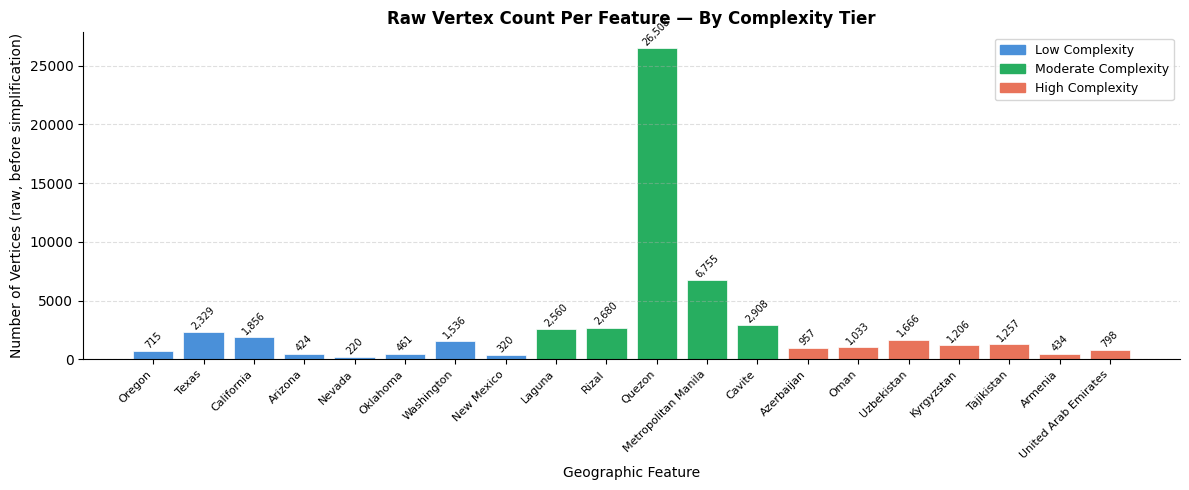

Saved as vertex_distribution.png


In [30]:
fig, ax = plt.subplots(figsize=(12, 5))

all_names  = us_names + ph_names + intl_names
all_tiers  = (['Low'] * len(us_names) +
               ['Moderate'] * len(ph_names) +
               ['High'] * len(intl_names))
all_counts = []

gdfs   = [gdf_us] * len(us_names) + [gdf_ph] * len(ph_names) + [gdf_intl] * len(intl_names)
n_cols = ['name'] * len(us_names) + ['NAME_1'] * len(ph_names) + ['NAME_EN'] * len(intl_names)

for gdf, col, name in zip(gdfs, n_cols, all_names):
    row = gdf[gdf[col] == name]
    if row.empty:
        all_counts.append(0)
    else:
        all_counts.append(count_vertices(row.iloc[0].geometry))

colors = {'Low': '#4A90D9', 'Moderate': '#27AE60', 'High': '#E8735A'}
bar_colors = [colors[t] for t in all_tiers]

bars = ax.bar(all_names, all_counts, color=bar_colors, edgecolor='white', linewidth=0.5)

for bar, count in zip(bars, all_counts):
    if count > 0:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
                f'{count:,}', ha='center', va='bottom', fontsize=7, rotation=45)

handles = [mpatches.Patch(color=c, label=f'{t} Complexity') for t, c in colors.items()]
ax.legend(handles=handles, fontsize=9)
ax.set_title('Raw Vertex Count Per Feature — By Complexity Tier', fontsize=12, fontweight='bold')
ax.set_ylabel('Number of Vertices (raw, before simplification)')
ax.set_xlabel('Geographic Feature')
plt.xticks(rotation=45, ha='right', fontsize=8)
ax.grid(axis='y', linestyle='--', alpha=0.4)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('vertex_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved as vertex_distribution.png')

---
## 7. Key Takeaways

| Observation | Implication for SEA-DP |
|---|---|
| Geospatial data is not tabular — coordinates ARE the data | Standard CSV tools don't apply; GeoPandas + Shapely are required |
| Vertex counts vary massively across tiers | Algorithm performance will differ meaningfully per tier |
| Philippine provinces have interior rings (Laguna de Bay) | Holes must be preserved separately — not processed as shared edges |
| All features share at least one boundary with a neighbor | Shared-edge detection is always applicable |
| Some raw geometries may already be invalid | Preprocessing (make_valid) must run before any simplification |

---
*This notebook shows the raw data only. For the SEA-DP algorithm and evaluation results, see the main thesis documentation.*